In [1]:
# 1. Import Library
import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from datetime import datetime
import pandas as pd
import os
from src.image_loader import load_mnist_images, load_mnist_labels
from src.image_preprocessor import preprocess_mnist
from src.image_generators import VAE, GAN
from src.text_preprocessor import split_into_sentences
from src.text_generators import PretrainedEmbedder, FullAttnResLLM, LSTMLLM


/mnt/nas-hpg9/eleazartadeo/miniconda3/envs/RAGFramework/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 2. Set Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Shape Gambar Data Latih: (60000, 28, 28)
Shape Label Data Latih: (60000,)


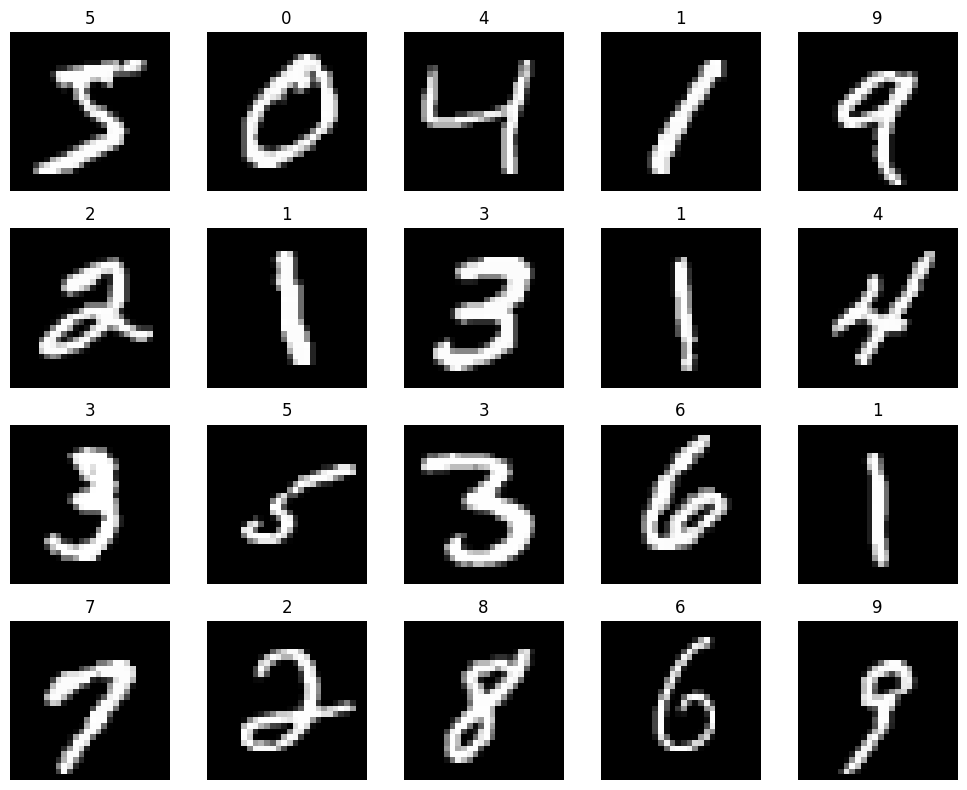

In [3]:
# 3. Load Dataset Vision

# 3.1. Load data latih dan data uji dari file yang sudah di download
x_train = load_mnist_images("dataset/image/train-images-idx3-ubyte")
y_train = load_mnist_labels("dataset/image/train-labels-idx1-ubyte")

x_test = load_mnist_images("dataset/image/t10k-images-idx3-ubyte")
y_test = load_mnist_labels("dataset/image/t10k-labels-idx1-ubyte")

# 3.2. Print shape atau bentuk gambar dan label data latih
print(f"Shape Gambar Data Latih: {x_train.shape}")
print(f"Shape Label Data Latih: {y_train.shape}")

# 3.3. Menunjukkan contoh sampel gambar data latih beserta labelnya
rows = 4
cols = 5
fig, axes = plt.subplots(rows, cols, figsize=(10, 8))

for i in range(rows * cols):
    r = i // cols
    c = i % cols

    axes[r, c].imshow(x_train[i], cmap='gray')
    axes[r, c].set_title(y_train[i])
    axes[r, c].axis('off')

plt.tight_layout()
plt.show()

In [4]:
# 4. Preprocessing Dataset Vision

# 4.1. Melakukan preprocessing terhadap data latih
x_train, y_train = preprocess_mnist(
    x_train,
    y_train,
    normalize=True,
    flatten=True,
    one_hot=False
)

# 4.2. Menunjukkan contoh sampel gambar data latih beserta labelnya yang sudah di preprocess
print(f"Shape Gambar Data Latih (Preprocessed): {x_train.shape}")
print(f"Shape Label Data Latih (Preprocessed): {y_train.shape}")

# 4.3. Mengubah x_train dan y_train menjadi bentuk tensor untuk dijadikan tensor dataset
x_train_tensor = torch.tensor(
    x_train,
    dtype=torch.float32,
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long,
)

# 4.4. Menjadikan x_train_tensor dan y_train_tensor menjadi tensor dataset
train_dataset = TensorDataset(
    x_train_tensor,
    y_train_tensor,
)

# 4.5. Menjadikan train_dataset menjadi sebuah data loader untuk di training
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
)


Shape Gambar Data Latih (Preprocessed): (60000, 784)
Shape Label Data Latih (Preprocessed): (60000,)


### 5. Definisi Model Generatif Vision
Model Generatif Vision adalah jenis kecerdasan buatan (Generative AI) yang dilatih untuk mempelajari pola visual dari data gambar atau video dalam jumlah besar, lalu menggunakan pola tersebut untuk menciptakan konten visual baru yang orisinal dan mirip dengan data latihannya.

### 6. Penjelasan Rumus Model Vision

#### 6.1. Konsep Dasar Generative Model
Model generatif berusaha mempelajari distribusi data:

$$
p(x)
$$

atau distribusi bersyarat:

$$
p(x|c)
$$

- $x$ = data yang ingin dihasilkan, misalnya gambar atau teks, variabel ini merepresentasikan sampel data yang dipelajari atau dihasilkan oleh model generatif.
- $c$ = kondisi, misalnya prompt, label, atau input tertentu, atau berupa informasi tambahan yang digunakan model untuk mengontrol hasil generasi data.
- $p(x)$ = peluang kemunculan data, distribusi probabilitas yang menunjukkan seberapa mungkin suatu data muncul pada dataset.
- $p(x|c)$ = peluang menghasilkan data berdasarkan kondisi tertentu, distribusi probabilitas data dengan mempertimbangkan kondisi atau konteks yang diberikan.

Pada kode PyTorch:

- VAE dan GAN mempelajari distribusi gambar.
- Full Attention Residual Transformer dan LSTM mempelajari distribusi token bahasa.

#### 6.2. Autoencoder

$$
z = f_{\theta}(x)
$$

$$
\hat{x} = g_{\phi}(z)
$$

$$
L = \|x - \hat{x}\|^2
$$

- $x$ = input asli atau data asli yang dimasukkan ke model, misalnya gambar atau sequence token.
- $z$ = latent vector, adalah representasi fitur berdimensi lebih kecil yang menyimpan informasi penting dari input.
- $\hat{x}$ = hasil rekonstruksi, data hasil decoder yang berusaha menyerupai input asli.
- $f_{\theta}$ = encoder, adalah fungsi atau jaringan neural yang mengubah input menjadi latent vector.
- $g_{\phi}$ = decoder, fungsi atau jaringan neural yang mengubah latent vector kembali menjadi data.
- $L$ = reconstruction loss, adalah nilai error yang mengukur seberapa dekat hasil rekonstruksi dengan data asli.

<div align="center">

| Konsep              | Kode PyTorch           |
| ------------------- | ---------------------- |
| Encoder             | `self.encoder(x)`      |
| Decoder             | `self.decoder(z)`      |
| Reconstruction Loss | `F.mse_loss(x_hat, x)` |

</div>

#### 6.3. Variational Autoencoder
$$
q_{\phi}(z|x)
$$

$$
z = \mu + \sigma \cdot \epsilon
$$

$$
\epsilon \sim \mathcal{N}(0, I)
$$

$$
L = L_{\text{reconstruction}} + L_{KL}
$$

$$
L_{KL} = D_{KL}(q_{\phi}(z|x) \parallel p(z))
$$

- $\mu$ = mean latent, adalah nilai rata-rata distribusi latent yang dipelajari encoder untuk setiap dimensi latent.
- $\sigma$ = standar deviasi latent, nilai penyebaran distribusi latent yang menentukan tingkat variasi sampling.
- $\epsilon$ = noise acak, sampel random dari distribusi normal yang digunakan pada reparameterization trick.
- $q_{\phi}(z|x)$ = distribusi latent dari input, atau distribusi probabilitas latent yang diprediksi encoder berdasarkan input tertentu.
- $p(z)$ = distribusi prior, atau distribusi referensi latent yang digunakan agar ruang latent tetap terstruktur, biasanya normal standar.
- $D_{KL}$ = KL divergence, adalah ukuran perbedaan antara distribusi latent encoder dan distribusi prior.

<div align='center'>

| Konsep             | Kode PyTorch                 |
| ------------------ | ---------------------------- |
| Mean latent        | `mu = self.fc_mu(h)`         |
| Variance latent    | `logvar = self.fc_logvar(h)` |
| Reparameterization | `z = mu + eps * std`         |
| KL Loss            | `kl_loss = ...`              |
</div>

#### 6.4. Generative Adversarial Network (GAN)

$$
\min_G \max_D V(D, G)
$$

$$
V(D,G)=\mathbb{E}_{x \sim p_{data}(x)}[\log D(x)] + \mathbb{E}_{z \sim p_z(z)}[\log(1 - D(G(z)))]
$$

- $G$ = generator, jaringan neural yang menghasilkan data palsu dari random noise.
- $D$ = discriminator, jaringan neural yang membedakan data asli dan data palsu.
- $x$ = data asli, atau sampel nyata dari dataset yang digunakan saat training.
- $z$ = noise acak, vektor random yang menjadi input generator untuk membuat data baru.
- $G(z)$ = data palsu yang dibuat generator, output generator yang diharapkan menyerupai data asli.
- $D(x)$ = probabilitas data dianggap asli, nilai prediksi discriminator mengenai kemungkinan suatu data berasal dari dataset nyata.

<div align='center'>

| Konsep        | Kode PyTorch                          |
| ------------- | ------------------------------------- |
| Generator     | `self.generator(z)`                   |
| Discriminator | `self.discriminator(real_images)`     |
| Fake image    | `fake_images = self.generate_fake(z)` |
| GAN Loss      | `nn.BCEWithLogitsLoss()`              |

</div>

#### 6.5. Diffusion Model

$$
x_t = \sqrt{\alpha_t} x_0 + \sqrt{1 - \alpha_t}\,\epsilon
$$

$$
\epsilon \sim \mathcal{N}(0, I)
$$

$$
L = \|\epsilon - \epsilon_{\theta}(x_t, t)\|^2
$$

- $x_0$ = gambar asli.
- $x_t$ = gambar yang sudah diberi noise.
- $\epsilon$ = noise asli.
- $\epsilon_{\theta}$ = noise yang diprediksi model.
- $t$ = timestep, tahapan proses diffusion yang menunjukkan tingkat noise pada data.
- $\alpha_t$ = koefisien noise, parameter yang mengatur proporsi informasi asli dan noise pada timestep tertentu.


In [5]:
# Membuat folder untuk menyimpan semua gambar dan hasil eksperimen (berlaku untuk teks juga)
def get_timestamp() -> str:
    return datetime.now().strftime("%Y%m%d-%H%M%S")

def create_folder(path:str) -> str:
    os.makedirs(path, exist_ok=True)
    return path

run_path = create_folder(f"outputs/run-{get_timestamp()}")

Training VAE-5e-64ld
Epoch [1] | epoch_time: 0.003344 | kl_loss: 0.000093 | loss: 0.070299 | recon_loss: 0.070206
Epoch [2] | epoch_time: 0.003062 | kl_loss: 0.000049 | loss: 0.067571 | recon_loss: 0.067523
Epoch [3] | epoch_time: 0.003094 | kl_loss: 0.000043 | loss: 0.067500 | recon_loss: 0.067457
Epoch [4] | epoch_time: 0.003056 | kl_loss: 0.000030 | loss: 0.067449 | recon_loss: 0.067419
Epoch [5] | epoch_time: 0.003024 | kl_loss: 0.000022 | loss: 0.067406 | recon_loss: 0.067384

=== Training Complete ===
  Total Time: 14.62s (0.24m)
Model saved to: outputs/run-20260511-073150/image/VAE-5e-64ld/checkpoints


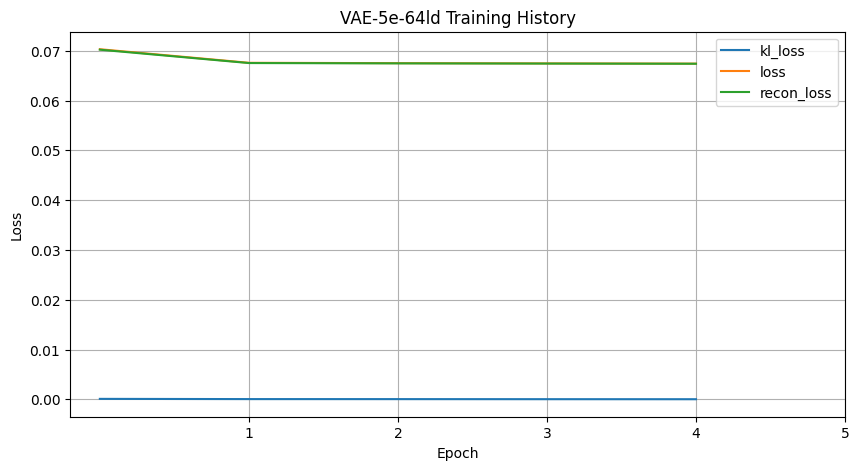

Training VAE-5e-128ld
Epoch [1] | epoch_time: 0.003029 | kl_loss: 0.000396 | loss: 0.070128 | recon_loss: 0.069733
Epoch [2] | epoch_time: 0.003050 | kl_loss: 0.001412 | loss: 0.067166 | recon_loss: 0.065754
Epoch [3] | epoch_time: 0.003075 | kl_loss: 0.001568 | loss: 0.067018 | recon_loss: 0.065450
Epoch [4] | epoch_time: 0.002920 | kl_loss: 0.001553 | loss: 0.066992 | recon_loss: 0.065440
Epoch [5] | epoch_time: 0.003029 | kl_loss: 0.001573 | loss: 0.066931 | recon_loss: 0.065358

=== Training Complete ===
  Total Time: 14.17s (0.24m)
Model saved to: outputs/run-20260511-073150/image/VAE-5e-128ld/checkpoints


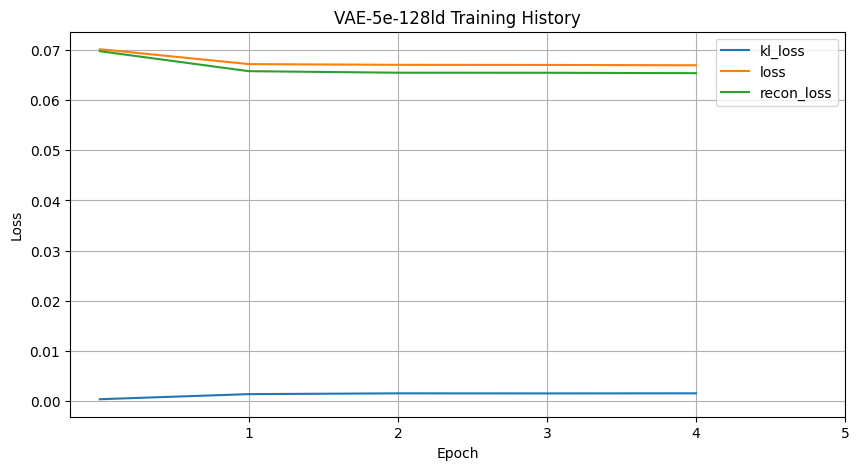

Training VAE-20e-64ld
Epoch [1] | epoch_time: 0.003047 | kl_loss: 0.000091 | loss: 0.070386 | recon_loss: 0.070294
Epoch [2] | epoch_time: 0.003064 | kl_loss: 0.000054 | loss: 0.067575 | recon_loss: 0.067521
Epoch [3] | epoch_time: 0.003032 | kl_loss: 0.000044 | loss: 0.067467 | recon_loss: 0.067423
Epoch [4] | epoch_time: 0.003052 | kl_loss: 0.000036 | loss: 0.067430 | recon_loss: 0.067394
Epoch [5] | epoch_time: 0.003043 | kl_loss: 0.000021 | loss: 0.067394 | recon_loss: 0.067374
Epoch [6] | epoch_time: 0.003037 | kl_loss: 0.000017 | loss: 0.067364 | recon_loss: 0.067347
Epoch [7] | epoch_time: 0.003036 | kl_loss: 0.000015 | loss: 0.067346 | recon_loss: 0.067331
Epoch [8] | epoch_time: 0.003041 | kl_loss: 0.000010 | loss: 0.067334 | recon_loss: 0.067324
Epoch [9] | epoch_time: 0.003044 | kl_loss: 0.000008 | loss: 0.067323 | recon_loss: 0.067315
Epoch [10] | epoch_time: 0.003040 | kl_loss: 0.000009 | loss: 0.067311 | recon_loss: 0.067301
Epoch [11] | epoch_time: 0.003046 | kl_loss: 0.

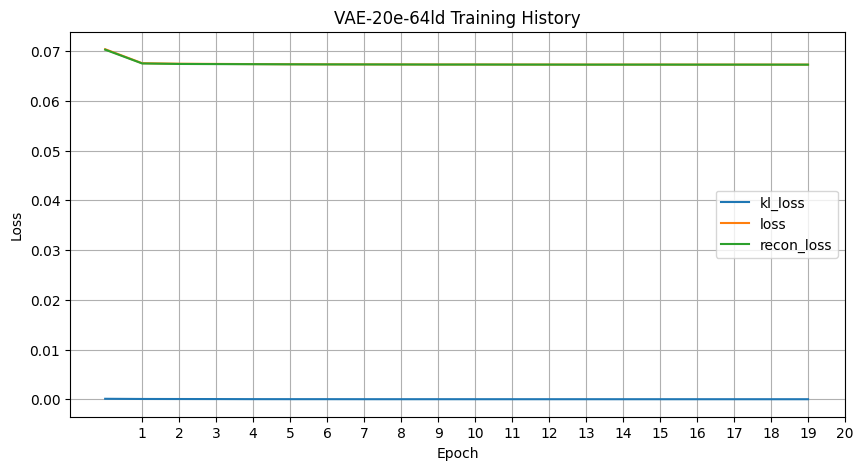

Training VAE-20e-128ld
Epoch [1] | epoch_time: 0.003049 | kl_loss: 0.000378 | loss: 0.070165 | recon_loss: 0.069788
Epoch [2] | epoch_time: 0.003051 | kl_loss: 0.001415 | loss: 0.067211 | recon_loss: 0.065796
Epoch [3] | epoch_time: 0.003055 | kl_loss: 0.001535 | loss: 0.067041 | recon_loss: 0.065506
Epoch [4] | epoch_time: 0.003069 | kl_loss: 0.001579 | loss: 0.066922 | recon_loss: 0.065343
Epoch [5] | epoch_time: 0.003069 | kl_loss: 0.001571 | loss: 0.066948 | recon_loss: 0.065377
Epoch [6] | epoch_time: 0.003066 | kl_loss: 0.001637 | loss: 0.066898 | recon_loss: 0.065260
Epoch [7] | epoch_time: 0.003058 | kl_loss: 0.001588 | loss: 0.066871 | recon_loss: 0.065283
Epoch [8] | epoch_time: 0.003059 | kl_loss: 0.001669 | loss: 0.066872 | recon_loss: 0.065203
Epoch [9] | epoch_time: 0.003066 | kl_loss: 0.001630 | loss: 0.066831 | recon_loss: 0.065201
Epoch [10] | epoch_time: 0.003069 | kl_loss: 0.001668 | loss: 0.066740 | recon_loss: 0.065072
Epoch [11] | epoch_time: 0.003062 | kl_loss: 0

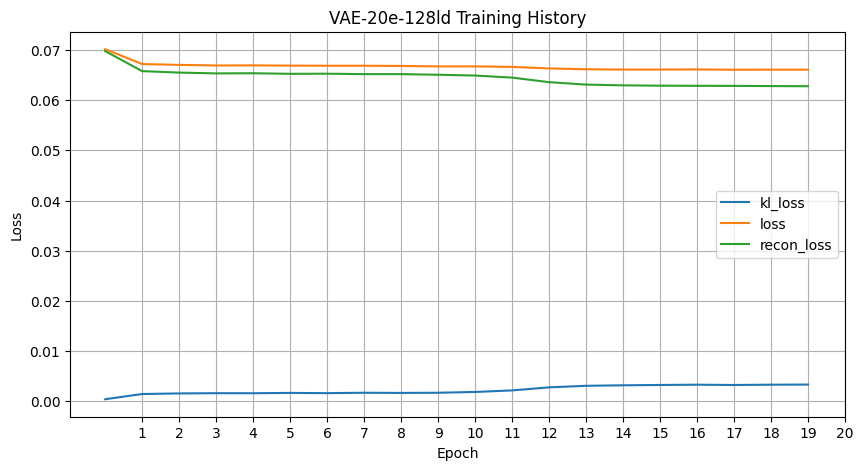

Training GAN-5e-64ld
Epoch [1] | d_loss: 0.311534 | epoch_time: 0.004488 | g_loss: 3.092105
Epoch [2] | d_loss: 0.018988 | epoch_time: 0.004467 | g_loss: 5.948112
Epoch [3] | d_loss: 0.011309 | epoch_time: 0.004473 | g_loss: 6.786989
Epoch [4] | d_loss: 0.008919 | epoch_time: 0.004376 | g_loss: 7.670013
Epoch [5] | d_loss: 0.007979 | epoch_time: 0.004373 | g_loss: 8.306163

=== Training Complete ===
  Total Time: 20.80s (0.35m)
Model saved to: outputs/run-20260511-073150/image/GAN-5e-64ld/checkpoints


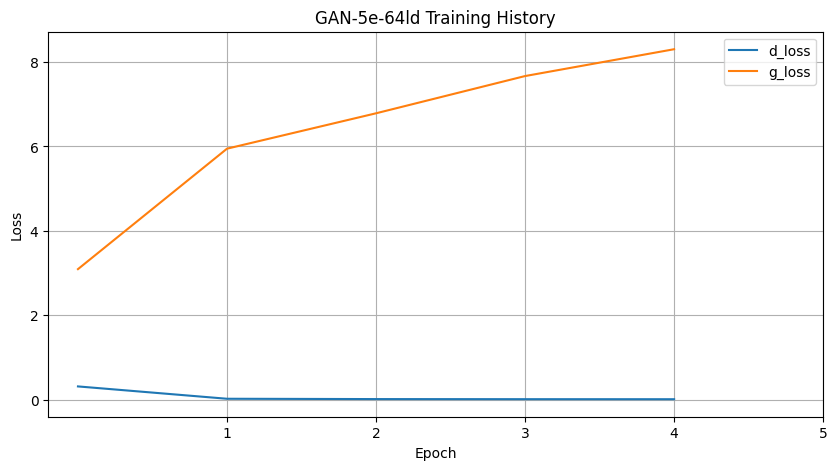

Training GAN-5e-128ld
Epoch [1] | d_loss: 0.286462 | epoch_time: 0.004407 | g_loss: 3.149740
Epoch [2] | d_loss: 0.018401 | epoch_time: 0.004411 | g_loss: 5.720235
Epoch [3] | d_loss: 0.010084 | epoch_time: 0.004377 | g_loss: 7.386956
Epoch [4] | d_loss: 0.006563 | epoch_time: 0.004368 | g_loss: 7.603390
Epoch [5] | d_loss: 0.005528 | epoch_time: 0.004429 | g_loss: 8.665724

=== Training Complete ===
  Total Time: 20.63s (0.34m)
Model saved to: outputs/run-20260511-073150/image/GAN-5e-128ld/checkpoints


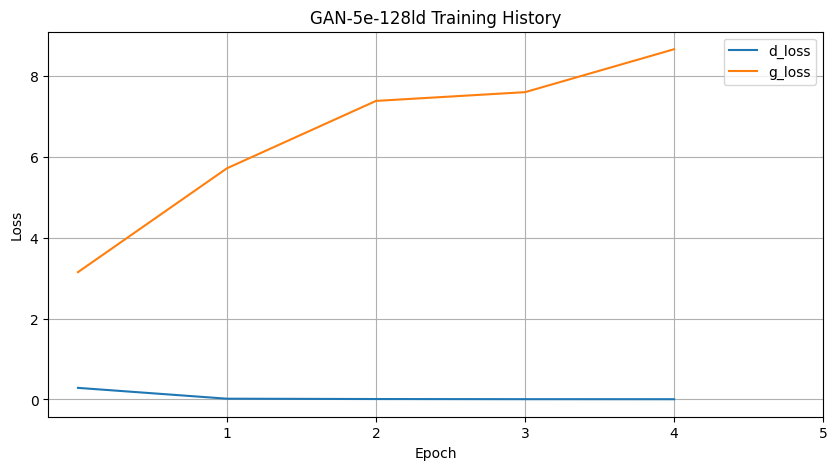

Training GAN-20e-64ld
Epoch [1] | d_loss: 0.298168 | epoch_time: 0.004395 | g_loss: 3.106046
Epoch [2] | d_loss: 0.016806 | epoch_time: 0.004406 | g_loss: 6.062956
Epoch [3] | d_loss: 0.007208 | epoch_time: 0.004404 | g_loss: 7.010454
Epoch [4] | d_loss: 0.005980 | epoch_time: 0.004349 | g_loss: 7.634253
Epoch [5] | d_loss: 0.012117 | epoch_time: 0.004353 | g_loss: 9.295687
Epoch [6] | d_loss: 0.006587 | epoch_time: 0.004346 | g_loss: 7.753219
Epoch [7] | d_loss: 0.012090 | epoch_time: 0.004422 | g_loss: 8.653774
Epoch [8] | d_loss: 0.006200 | epoch_time: 0.004413 | g_loss: 9.260285
Epoch [9] | d_loss: 0.007791 | epoch_time: 0.004385 | g_loss: 10.464390
Epoch [10] | d_loss: 0.011035 | epoch_time: 0.004464 | g_loss: 11.254642
Epoch [11] | d_loss: 0.009636 | epoch_time: 0.004374 | g_loss: 11.686493
Epoch [12] | d_loss: 0.008679 | epoch_time: 0.004459 | g_loss: 10.147597
Epoch [13] | d_loss: 0.011830 | epoch_time: 0.004446 | g_loss: 13.464060
Epoch [14] | d_loss: 0.057461 | epoch_time: 0.

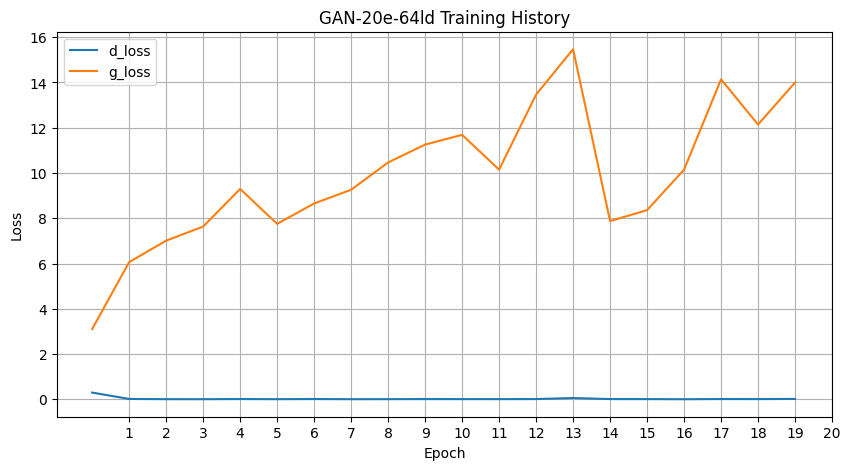

Training GAN-20e-128ld
Epoch [1] | d_loss: 0.291995 | epoch_time: 0.004539 | g_loss: 3.224958
Epoch [2] | d_loss: 0.014229 | epoch_time: 0.004540 | g_loss: 6.045535
Epoch [3] | d_loss: 0.006944 | epoch_time: 0.004519 | g_loss: 6.785676
Epoch [4] | d_loss: 0.004024 | epoch_time: 0.004519 | g_loss: 7.487269
Epoch [5] | d_loss: 0.005861 | epoch_time: 0.004470 | g_loss: 8.206178
Epoch [6] | d_loss: 0.005095 | epoch_time: 0.004516 | g_loss: 9.663757
Epoch [7] | d_loss: 0.006503 | epoch_time: 0.004496 | g_loss: 9.768729
Epoch [8] | d_loss: 0.008829 | epoch_time: 0.004512 | g_loss: 12.729908
Epoch [9] | d_loss: 0.011782 | epoch_time: 0.004532 | g_loss: 10.149814
Epoch [10] | d_loss: 0.006586 | epoch_time: 0.004474 | g_loss: 9.274700
Epoch [11] | d_loss: 0.005990 | epoch_time: 0.004436 | g_loss: 8.722788
Epoch [12] | d_loss: 0.003447 | epoch_time: 0.004386 | g_loss: 10.405302
Epoch [13] | d_loss: 0.013460 | epoch_time: 0.004385 | g_loss: 14.266125
Epoch [14] | d_loss: 0.013185 | epoch_time: 0.

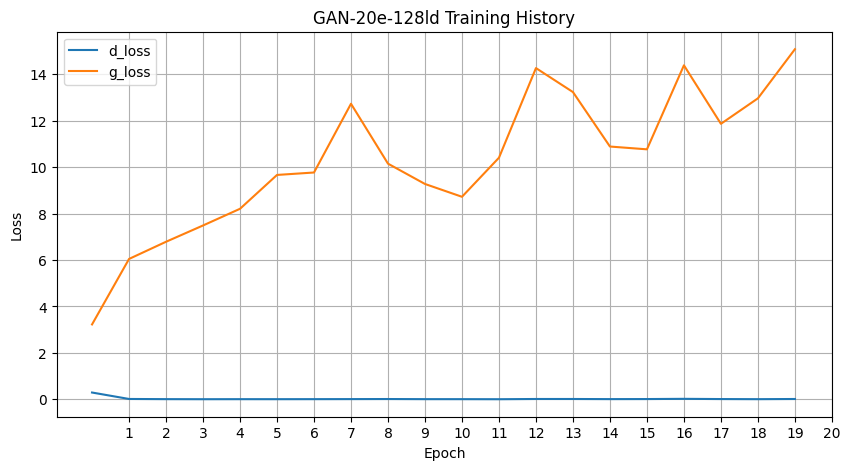

In [6]:
# 7. Training Model Vision

# 7.1. Membuat dictionary model yang digunakan beserta confignya

# 7.1.1. Variabel konstan untuk mempermudah edit eskperimen bersamaan
E5 = 5
E20 = 20
LD64 = 64
LD128 = 128

# 7.1.2. Dictionary model yang digunakan beserta confignya berdasarkan variabel konstan yang sudah ditetapkan
models = {
        f"VAE-{E5}e-{LD64}ld": {
            "model": VAE,
            "config": {
                'latent_dim': LD64,
                'hidden_dim': 128,
                'epochs': E5,
            },
        },
        f"VAE-{E5}e-{LD128}ld": {
            "model": VAE,
            "config": {
                'latent_dim': LD128,
                'hidden_dim': 128,
                'epochs': E5,
            },
        },
        f"VAE-{E20}e-{LD64}ld": {
            "model": VAE,
            "config": {
                'latent_dim': LD64,
                'hidden_dim': 128,
                'epochs': E20,
            },
        },
        f"VAE-{E20}e-{LD128}ld": {
            "model": VAE,
            "config": {
                'latent_dim': LD128,
                'hidden_dim': 128,
                'epochs': E20,
            },
        },
        f"GAN-{E5}e-{LD64}ld": {
            "model": GAN,
            "config": {
                'latent_dim': LD64,
                'hidden_dim': 128,
                'epochs': E5,
            }
        },
        f"GAN-{E5}e-{LD128}ld": {
            "model": GAN,
            "config": {
                'latent_dim': LD128,
                'hidden_dim': 128,
                'epochs': E5,
            }
        },
        f"GAN-{E20}e-{LD64}ld": {
            "model": GAN,
            "config": {
                'latent_dim': LD64,
                'hidden_dim': 128,
                'epochs': E20,
            }
        },
        f"GAN-{E20}e-{LD128}ld": {
            "model": GAN,
            "config": {
                'latent_dim': LD128,
                'hidden_dim': 128,
                'epochs': E20,
            }
        },
    }

# 7.2. Membuat dictionary history kosong untuk menyimpan semua hasil training eksperimen image generation
histories = {}

# 7.3.1. Membuat folder untuk menyimpan semua gambar dan hasil eksperimen khusus eksperimen image
image_path = create_folder(f"{run_path}/image")

# 7.4. Melakukan proses training dan menyimpan hasil model beserta historynya kedalam dictionary histories
for exp_name, exp_data in models.items():

    # 7.4.1. Ekstrak model dan konfigurasi dari dictionary yang sudah dibuat sebelumnya
    model_class = exp_data["model"]
    config = exp_data["config"]

    # 7.4.2. Instansiasi model
    model = model_class(
        input_dim=x_train.shape[1],
        latent_dim=config["latent_dim"],
        hidden_dim=config["hidden_dim"],
        device=device
    ).to(device)

    # 7.4.3. Melakukan proses training dengan menunjukkan proses epoch beserta waktu dan lossnya.
    print("=" * 75)
    print(f"Training {exp_name}")
    print("=" * 75)
    history = model.train_model(
        dataloader=train_loader,
        epochs=config["epochs"],
        verbose=True,
        save_path=f"{image_path}/{exp_name}/checkpoints",
    )

    # 7.4.4. Visualisasi grafik training history (disimpan juga untuk dimasukkan dalam laporan)
    history.plot(
        title=f"{exp_name} Training History",
        save_path=f"{image_path}/{exp_name}/{exp_name}_training_history.png"
    )

    # 7.4.5. Menyimpan hasil training eksperimen image generation terhadap masing masing model
    histories[exp_name] = {
        "model": model,
        "history": history,
        "config": config,
    }


In [7]:
# 8. Generate Gambar Baru

# 8.1. Menentukan jumlah baris dan kolom visualisasi
rows = 4
cols = 5

# 8.2. Dictionary untuk menyimpan semua hasil generasi gambar
all_samples = {}

# 8.2. Melakukan generasi gambar masing masing yang sudah di untuk semua hasil generasi gambar
for exp_name, result in histories.items():

    model = result['model']

    samples = model.generate(rows * cols)

    print(f"Generated {len(samples)} images from {exp_name}")

    all_samples[exp_name] = samples

Generated 20 images from VAE-5e-64ld
Generated 20 images from VAE-5e-128ld
Generated 20 images from VAE-20e-64ld
Generated 20 images from VAE-20e-128ld
Generated 20 images from GAN-5e-64ld
Generated 20 images from GAN-5e-128ld
Generated 20 images from GAN-20e-64ld
Generated 20 images from GAN-20e-128ld


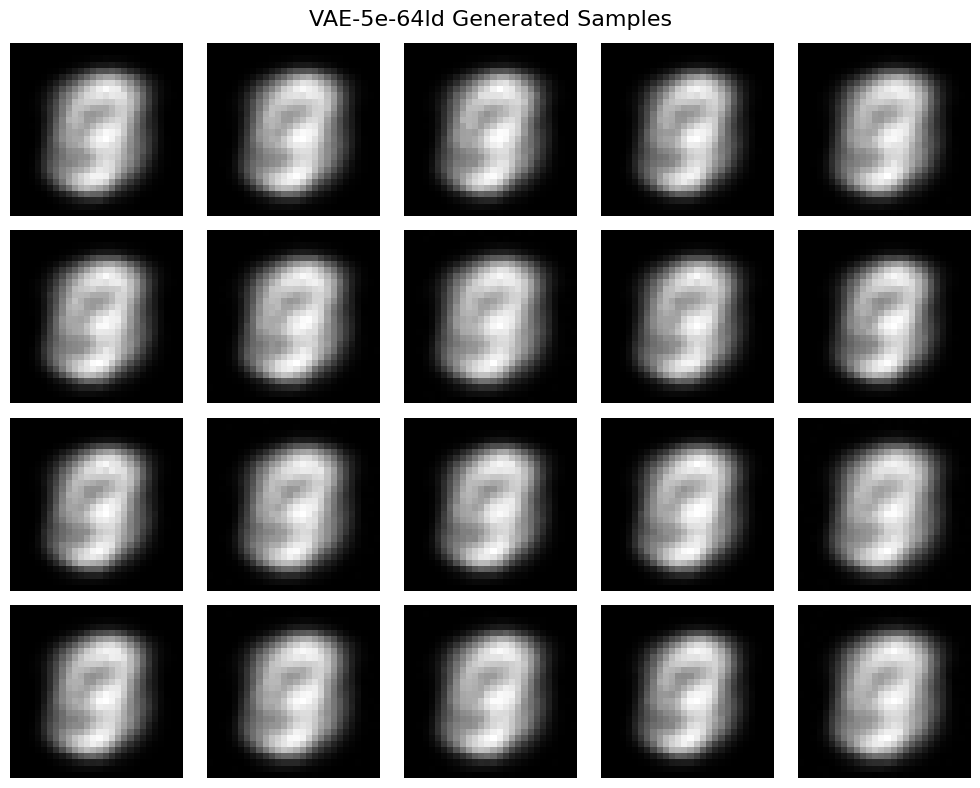

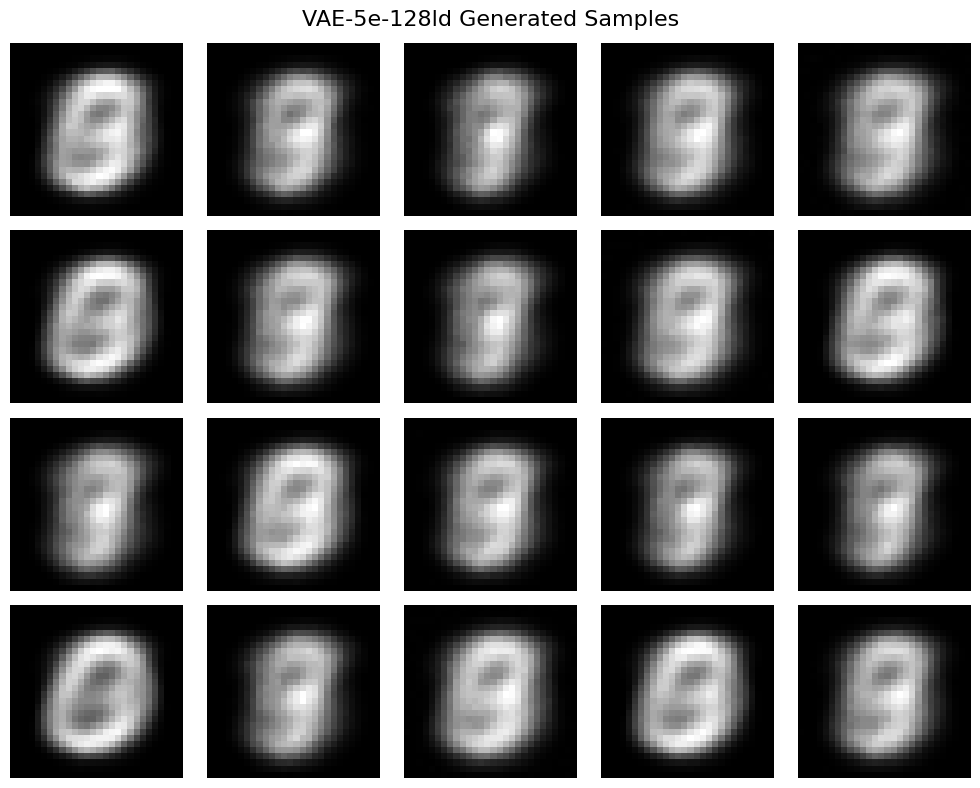

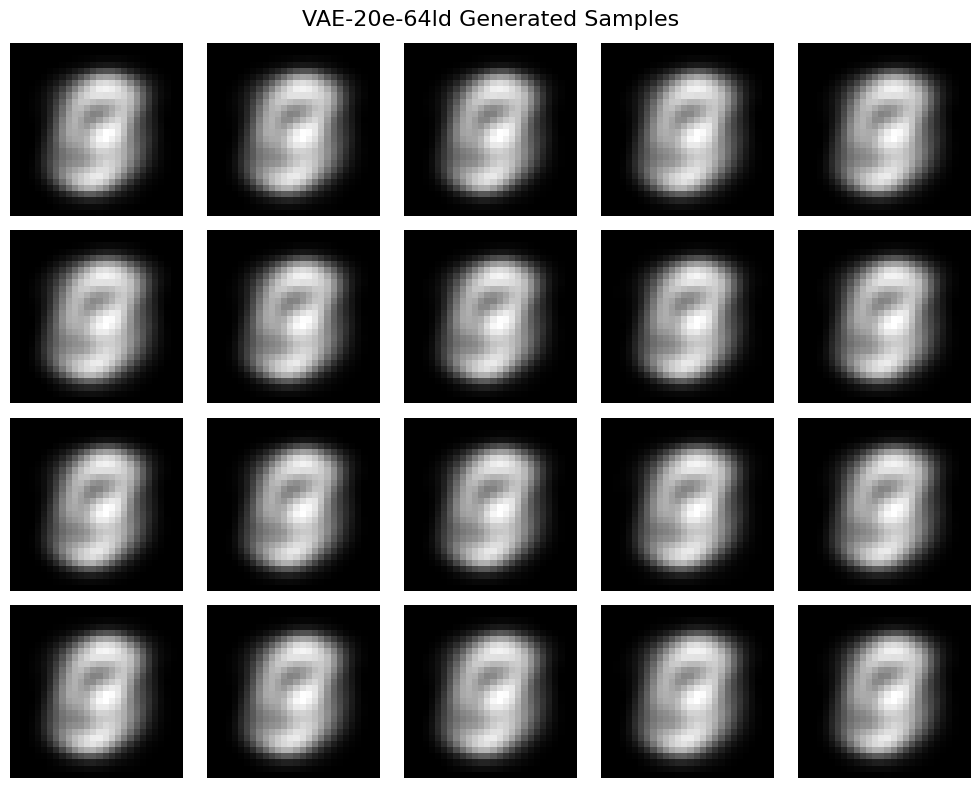

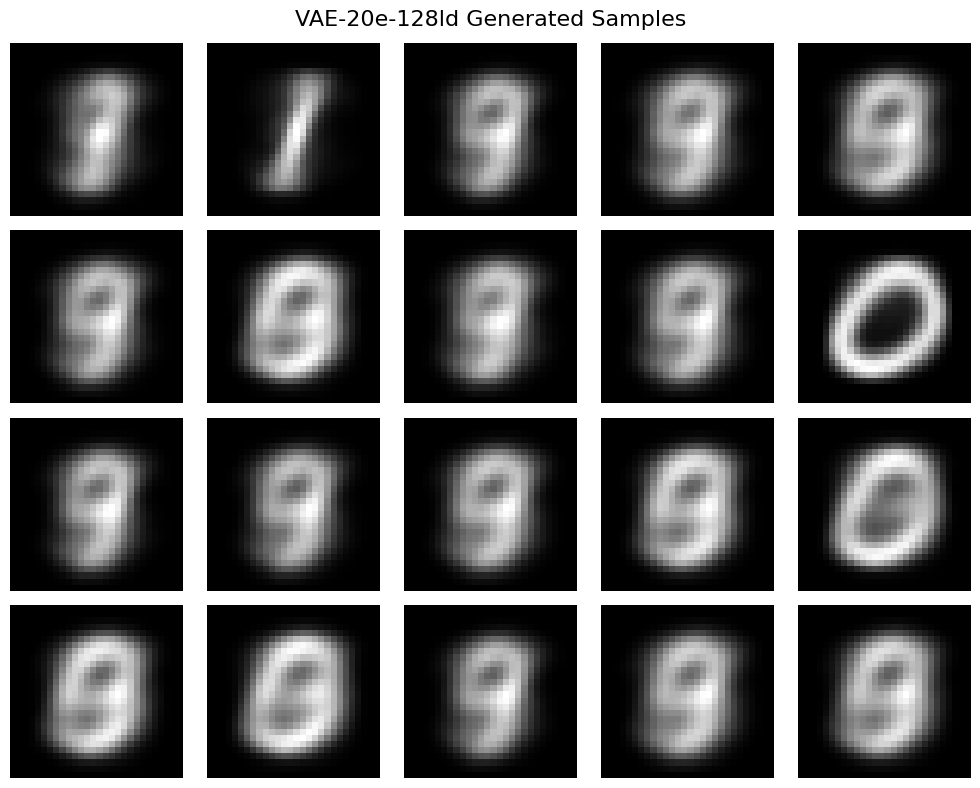

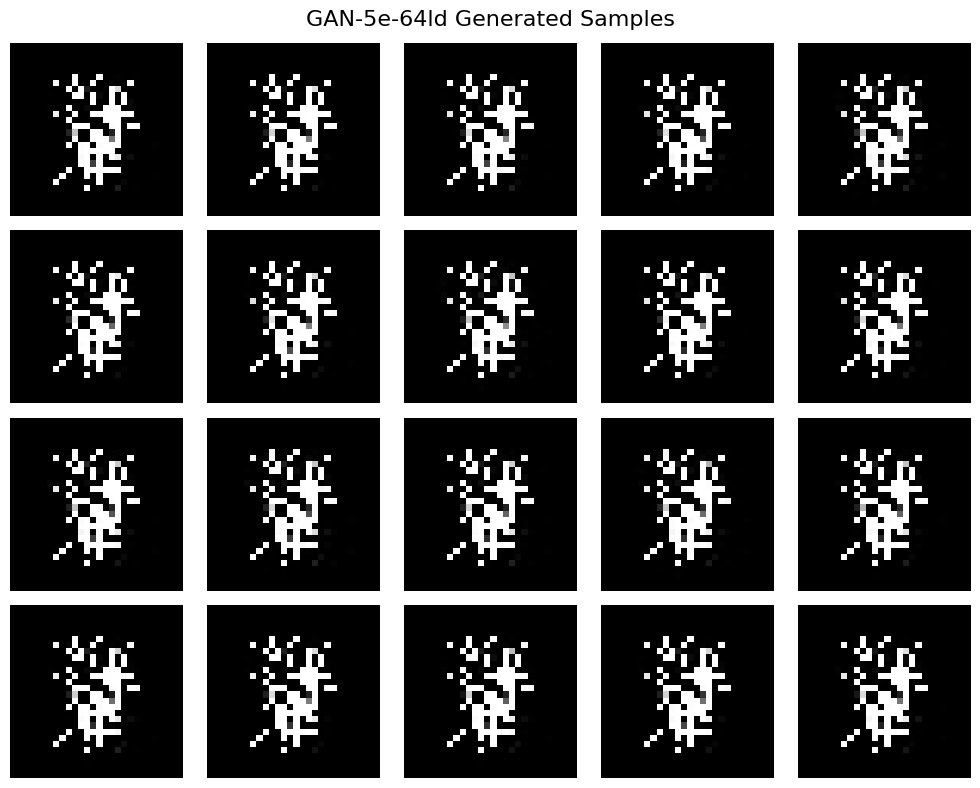

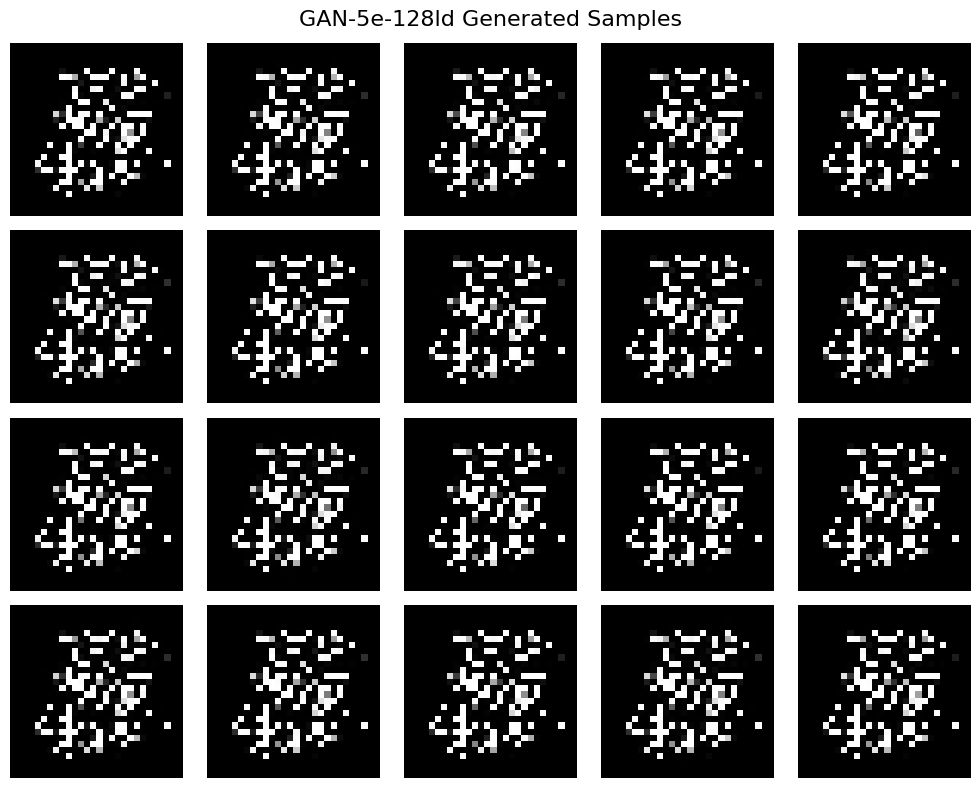

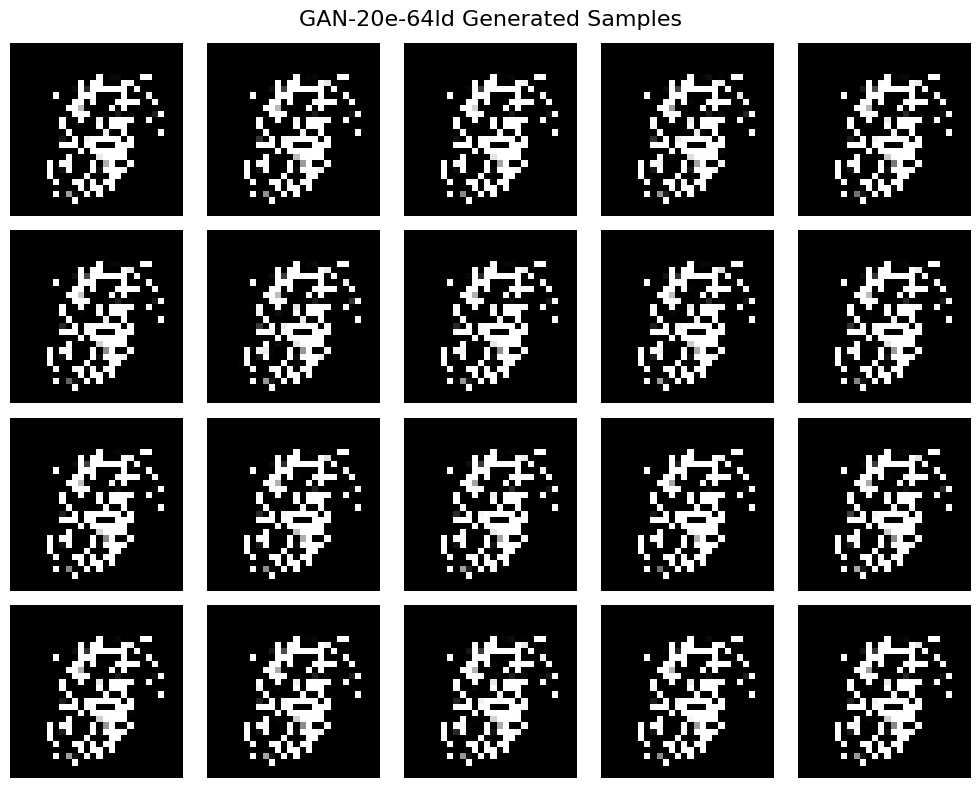

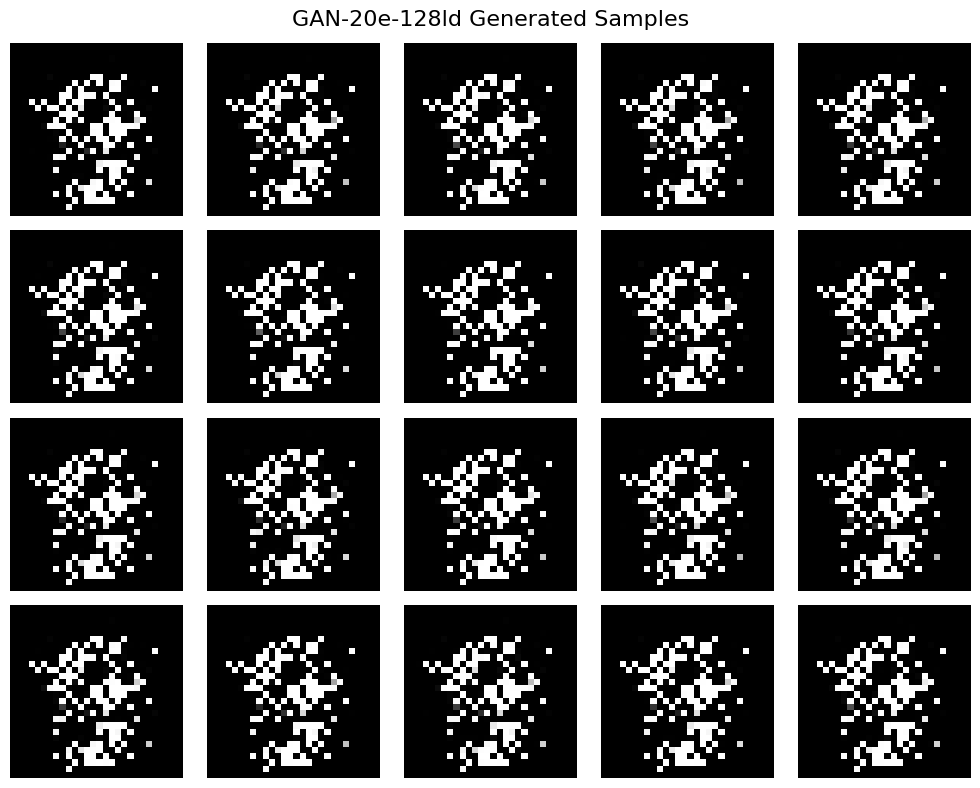

In [8]:
# 9. Visualisasi Hasil Vision

# 9.1. Iterasi untuk setiap model yang digunakan beserta sampel yang digenerasi sesuai dengan ketentuan jumlah sampel
# yang sudah didefinisikan sebelumnya, menampilkan gambar hasil generasi untuk perbandingan beserta menyimpannya untuk laporan

generated_image_path = create_folder(f"{image_path}/generated")
for model_name, samples in all_samples.items():
    fig, axes = plt.subplots(rows, cols, figsize=(10, 8))

    for i in range(rows*cols):
        r = i // cols
        c = i % cols

        axes[r, c].imshow(samples[i][0], cmap="gray")
        axes[r, c].axis("off")
        
    fig.suptitle(f"{model_name} Generated Samples", fontsize=16)
    plt.tight_layout()
    plt.savefig(f"{generated_image_path}/{model_name}-generated-samples.png", dpi=300, bbox_inches="tight")
    plt.show()


In [9]:
# 10. Load Dataset Text

# 10.1. Load dataset text dari csv
df = pd.read_csv("dataset/text/wikipedia_id-clean.csv")

# 10.2. Validasi dataset yang sudah di load
print("Kolom:", df.columns.tolist())
print("Sample judul:", df["title"].iloc[0])
print("Panjang teks pertama:", len(str(df["text"].iloc[0])))

Kolom: ['id', 'parent_id', 'timestamp', 'hash', 'title', 'text']
Sample judul: Asam deoksiribonukleat
Panjang teks pertama: 21763


In [10]:
# 11. Preprocessing Text

# 11.1. Membuat penyimpanan untuk data per topik wiki indonesia
data_per_topic = {}

# 11.2. Menentukan seberapa banyak topik yang ingin digunakan sebagai data latih
N_TOPICS = 50
for idx, row in df.head(N_TOPICS).iterrows():
    title = str(row["title"]).strip()
    text = str(row["text"])
    
    # 11.3. Skip judul kosong atau terlalu pendek
    if not title or len(title) < 3:
        continue
    
    # 11.4. Split kalimat
    sentences = split_into_sentences(text)
    
    # 11.5. Simpan hanya jika ada minimal 3 kalimat
    if len(sentences) >= 3:
        data_per_topic[title] = sentences

# 11.6. Cek jumlah total topik yang digunakan untuk data latih, beserta kategori topiknya
print(f"\nTotal topik: {len(data_per_topic)}")
print(f"Sample topik: {list(data_per_topic.keys())[:5]}")

# 11.7. Mengubah dari kalimat per topic menjadi 1 list of kalimat - kalimat
all_sentences = [
    sentence 
    for sentences in data_per_topic.values() 
    for sentence in sentences
]

# 11.8. Cek total kalimat dari seluruh topik yang digunakan untuk data latih
total_kalimat = len(all_sentences)
print(f"Total kalimat dari semua topik: {total_kalimat}")

# 11.9. Cek semua kalimat yang nantinya digunakan untuk data latih
for sentence in all_sentences:
    print(sentence)


Total topik: 49
Sample topik: ['Asam deoksiribonukleat', 'Anwar Sadat', 'Azhar Mansor', 'Arkeologi', 'Antropologi']
Total kalimat dari semua topik: 5332
Asam deoksiribonukleat, lebih dikenal dengan singkatan DNA (bahasa Inggris: deoxyribonucleic acid), adalah salah satu jenis asam nukleat yang memiliki kemampuan pewarisan sifat.
Keberadaan asam deoksiribonukleat ditemukan di dalam nukleoprotein yang membentuk inti sel.
James Dewey Watson dan Francis Crick merupakan ilmuwan pertama yang mengajukan model struktur DNA pada tahun 1953 dengan bentuk pilinan ganda.
Setiap DNA tersusun dari dua buah rantai polinukleotida.
DNA merupakan sejenis biomolekul yang menyimpan dan menyandi instruksi-instruksi genetika setiap organisme dan banyak jenis virus.
Instruksi-instruksi genetika ini berperan penting dalam pertumbuhan, perkembangan, dan fungsi organisme dan virus.
DNA merupakan asam nukleat; bersamaan dengan protein dan karbohidrat, asam nukleat adalah makromolekul esensial bagi seluruh makhl

### 12. Definisi Model Generatif Text
Model generatif teks adalah jenis kecerdasan buatan (AI) yang dirancang untuk mempelajari pola, struktur, dan hubungan dalam data teks pelatihan, kemudian menggunakan pengetahuan tersebut untuk menghasilkan konten teks baru yang orisinal, kontekstual, dan mirip dengan data aslinya.

### 13. Penjelasan Rumus Model Text
#### 13.1. Text Generation

Text generation dilakukan dengan memprediksi token satu per satu:

$$
p(x_1, x_2, ..., x_T) = \prod_{t=1}^{T} p(x_t \mid x_1, x_2, ..., x_{t-1})
$$

- $x_t$ = token pada posisi ke-$t$, yaitu token yang sedang diprediksi model.
- $x_1, ..., x_{t-1}$ = token sebelumnya, yaitu konteks sequence yang digunakan untuk memprediksi token berikutnya.
- $T$ = panjang sequence token yang dihasilkan model.
- Model memprediksi token berikutnya berdasarkan token sebelumnya.

<div align="center">

| Konsep                    | Kode PyTorch                         |
| ------------------------- | ------------------------------------ |
| Token Embedding           | `self.token_embedding(input_ids)`    |
| Next Token Prediction     | `target_ids = tokens[idx + 1 : ...]` |
| Autoregressive Generation | `generated = torch.cat(...)`         |
| Token Sampling            | `torch.multinomial(...)`             |

</div>

#### 13.2. Self-Attention Transformer

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

- $Q$ = query, representasi token yang digunakan untuk mencari informasi relevan dari token lain.
- $K$ = key, representasi token yang digunakan sebagai acuan pencocokan attention.
- $V$ = value, representasi informasi token yang akan dikombinasikan berdasarkan attention score.
- $d_k$ = dimensi key, jumlah dimensi pada vector key yang digunakan untuk normalisasi attention score.
- $\text{softmax}$ = mengubah skor menjadi bobot perhatian.

<div align="center">

| Konsep            | Kode PyTorch                               |
| ----------------- | ------------------------------------------ |
| Query Projection  | `self.q_proj(h_norm)`                      |
| Key Projection    | `self.k_proj(h_norm)`                      |
| Value Projection  | `self.v_proj(h_norm)`                      |
| Attention Score   | `torch.matmul(Q, K_seq.transpose(-2, -1))` |
| Attention Softmax | `F.softmax(scores, dim=-1)`                |

</div>


#### 13.3. Cross Entropy Loss untuk Text Generation

$$
L = -\sum_{i=1}^{N} y_i \log(\hat{y}_i)
$$

- $L$ = nilai loss, yaitu error antara prediksi model dan target sebenarnya.
- $y_i$ = token target sebenarnya.
- $\hat{y}_i$ = probabilitas token hasil prediksi.
- $N$ = jumlah token atau vocabulary class.

<div align="center">

| Konsep         | Kode PyTorch                          |
| -------------- | ------------------------------------- |
| Cross Entropy  | `F.cross_entropy(...)`                |
| Ignore Padding | `ignore_index=pad_token_id`           |
| Token Logits   | `logits.reshape(-1, logits.size(-1))` |


</div>

In [11]:
# Membuat folder untuk menyimpan semua gambar dan hasil eksperimen khusus eksperimen text
text_path = create_folder(f"{run_path}/text")

In [12]:
# 14. Training Model Text

# 14.1. Variabel konstan untuk mempermudah edit eskperimen bersamaan
EPOCHS = 5
DIM = 512
CTX_SIZE = 8
BATCH_SIZE = 1024
LR = 1e-4

# 14.2. Inisiasi embedder pretrained yang digunakan dalam training LLM yang dibuat
print("\n[1] Initializing Pretrained Embedder...")
embedder = PretrainedEmbedder(
    model_name="LazarusNLP/all-indo-e5-small-v4",
    projection_dim=DIM,
    device=device,
)

# 14.3. Training LLM dengan arsitektur full attention residual dari Kimi Team
print("\n" + "=" * 60)
print("[2] Training FullAttnResLLM")
print("=" * 60)

# 14.3.1. Inisiasi model
attnres_model = FullAttnResLLM(
    embedder=embedder,
    num_layers=4,
    num_heads=4,
    device=device
).to(device)

# 14.3.2. Menunjukkan jumlah parameter model
print(f"Parameters: {sum(p.numel() for p in attnres_model.parameters()):,}")

# 14.3.3. Training model Full Attention Residual Transformer
attnres_history = attnres_model.train_model(
    sentences=all_sentences,
    num_epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    context_size=CTX_SIZE,
    learning_rate=LR,
    print_every=5,
    save_path=f"{text_path}/attn-res/checkpoints",
)

# 14.3.4. Visualisasi grafik training history Full Attention Residual Transformer (disimpan juga untuk dimasukkan dalam laporan)
attnres_history.plot(
    title="FullAttnResLLM Training History",
    save_path=f"{text_path}/attn-res/FullAttnResLLM_training_history.png"
)

# 14.4. Training LLM dengan arsitektur LSTM
print("\n" + "=" * 60)
print("[3] Training LSTMLLM")
print("=" * 60)

# 14.4.1. Inisiasi model
lstm_model = LSTMLLM(
    embedder=embedder,
    num_layers=4,
    bidirectional=False,
    device=device
)

# 14.4.2. Menunjukkan jumlah parameter model
print(f"Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")

# 14.4.3. Training model LSTM
lstm_history = lstm_model.train_model(
    sentences=all_sentences,
    num_epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    context_size=CTX_SIZE,
    learning_rate=LR,
    print_every=5,
    save_path=f"{text_path}/lstm/chekpoints",
)

# 14.4.4. Visualisasi grafik training history LSTM (disimpan juga untuk dimasukkan dalam laporan)
lstm_history.plot(
    title="LSTMLLM Training History",
    save_path=f"{text_path}/lstm/LSTMLLM_training_history.png"
)


[1] Initializing Pretrained Embedder...
Loading embedder: LazarusNLP/all-indo-e5-small-v4



[2] Training FullAttnResLLM
Auto-detected dim from embedder: 512
Parameters: 135,122,560
Total tokens: 195396
Epoch 1/5 | Batch 5 | Loss: 12.413684
Epoch 1/5 | Batch 10 | Loss: 12.407126
Epoch 1/5 | Batch 15 | Loss: 12.401710
Epoch 1/5 | Batch 20 | Loss: 12.395288
Epoch 1/5 | Batch 25 | Loss: 12.389882
Epoch 1/5 | Batch 30 | Loss: 12.383844
Epoch 1/5 | Batch 35 | Loss: 12.375040
Epoch 1/5 | Batch 40 | Loss: 12.369555
Epoch 1/5 | Batch 45 | Loss: 12.364735
Epoch 1/5 | Batch 50 | Loss: 12.358227
Epoch 1/5 | Batch 55 | Loss: 12.350258
Epoch 1/5 | Batch 60 | Loss: 12.342300
Epoch 1/5 | Batch 65 | Loss: 12.339313
Epoch 1/5 | Batch 70 | Loss: 12.332995
Epoch 1/5 | Batch 75 | Loss: 12.322698
Epoch 1/5 | Batch 80 | Loss: 12.319072
Epoch 1/5 | Batch 85 | Loss: 12.315457
Epoch 1/5 | Batch 90 | Loss: 12.312362
Epoch 1/5 | Batch 95 | Loss: 12.303910
Epoch 1/5 | Batch 100 | Loss: 12.296336
Epoch 1/5 | Batch 105 | Loss: 12.282545
Epoch 1/5 | Batch 110 | Loss: 12.283841
Epoch 1/5 | Batch 115 | Loss:

TypeError: Object of type device is not JSON serializable

In [ ]:
# 15. Generate Text dari Prompt

# 15.1. Inisiasi list prompt yang digunakan untuk menguji model,
# terdiri dari 4 contoh masing masing prompt pendek, sedang, dan panjang
all_prompts = {
    "pendek": [
        "Gunung Semeru adalah",
        "Jakarta merupakan",
        "Kecerdasan buatan adalah",
        "Kerajaan Majapahit",
    ],
    "sedang": [
        "Gunung Semeru merupakan gunung berapi aktif di Jawa Timur yang memiliki ketinggian",
        "Kecerdasan buatan atau artificial intelligence adalah cabang ilmu komputer yang berfokus pada",
        "Kerajaan Majapahit dikenal sebagai salah satu kerajaan terbesar di Nusantara karena",
        "Jakarta sebagai ibu kota Indonesia memiliki peran penting dalam bidang ekonomi karena",
    ],
    "panjang": [
        "Gunung Semeru merupakan gunung berapi aktif yang terletak di Provinsi Jawa Timur, Indonesia. Gunung ini termasuk dalam kawasan Taman Nasional Bromo Tengger Semeru dan menjadi salah satu destinasi pendakian paling populer di Indonesia. Selain memiliki keindahan alam, Semeru juga dikenal karena aktivitas vulkaniknya yang cukup tinggi sehingga sering menjadi objek penelitian geologi.",
        "Kecerdasan buatan atau artificial intelligence adalah bidang ilmu komputer yang mempelajari bagaimana mesin dapat meniru kemampuan berpikir manusia. Teknologi ini digunakan dalam berbagai bidang seperti pengenalan wajah, kendaraan otonom, chatbot, hingga sistem rekomendasi pada media sosial dan e-commerce.",
        "Kerajaan Majapahit merupakan kerajaan Hindu-Buddha terbesar di Nusantara yang mencapai masa kejayaan pada masa pemerintahan Hayam Wuruk dan Mahapatih Gajah Mada. Kerajaan ini dikenal memiliki pengaruh besar terhadap perdagangan, budaya, dan politik di Asia Tenggara.",
        "Jakarta adalah ibu kota Indonesia sekaligus pusat pemerintahan, ekonomi, dan bisnis nasional. Kota ini memiliki populasi yang sangat besar dan menjadi pusat aktivitas perdagangan, transportasi, pendidikan, serta industri kreatif di Indonesia."
    ]
}

# 15.2. Generasi dengan Full Attention Residual Transformer (disimpan hasil prompt-generasi nya)
all_attn_res_results = {}
print("\n--- FullAttnResLLM Generation ---")
for length_type, prompts in all_prompts.items():
    attnres_results = attnres_model.generate_batch(
        prompts=prompts,
        max_length=20,
        temperature=0.8,
        save_path=f"{text_path}/generated/prompt_{length_type}_attnres_generated.md"
    )
    all_attn_res_results[length_type] = attnres_results

# 15.3. Menampilkan hasil generasi model Full Attention Residual Transformer dari prompt yang diberikan
for length_type, attnres_results in all_attn_res_results:
    print(f"=== Prompt {length_type.upper()} ===")
    for result in attnres_results:
        print(f"Prompt: '{result['prompt']}'")
        print(f"Generated: '{result['generated']}'")
        print()
    print("-" * 50)

# 15.4. Generasi dengan LSTM (disimpan hasil prompt-generasi nya)
all_lstm_results = {}
print("\n--- LSTMLLM Generation ---")
for length_type, prompts in all_prompts.items():
    lstm_results = lstm_model.generate_batch(
        prompts=prompts,
        max_length=20,
        temperature=0.8,
        save_path=f"{text_path}/generated/prompt_{length_type}_lstm_generated.md"
    )
    all_lstm_results[length_type] = lstm_results

# 15.5. Menampilkan hasil generasi model LSTM dari prompt yang diberikan
for length_type, lstm_results in all_lstm_results.items():
    print(f"=== Prompt {length_type.upper()} ===")
    for result in lstm_results:
        print(f"Prompt {length_type}")
        print(f"Prompt: '{result['prompt']}'")
        print(f"Generated: '{result['generated']}'")
        print()
    print("-" * 50)


In [ ]:
# 16. Visualisasi Loss

# 16.1. Visualisasi Loss Training Image
for exp_name, result in histories.items():
    history = result['history']
    history.plot(title=f"{exp_name} Training History")
    
# 17.2. Visualisasi Loss Training Text
attnres_history.plot(title="FullAttnResLLM Training History")
lstm_history.plot(title="LSTMLLM Training History")


### 17. Perbandingan Hasil
#### 17.1. Perbandingan Hasil Gambar
|Model|Kualitas gambar|Stabilitas training|Loss|Kemudahan implementasi|Apakah model menghasilkan data baru atau hanya merekonstruksi?|
|-|-|-|-|-|-| 
|VAE-5e-64ld|-|-|-|-|-| 
|VAE-5e-128ld|-|-|-|-|-| 
|VAE-20e-64ld|-|-|-|-|-| 
|VAE-20e-128ld|-|-|-|-|-|
|GAN-5e-64ld|-|-|-|-|-| 
|GAN-5e-128ld|-|-|-|-|-| 
|GAN-20e-64ld|-|-|-|-|-| 
|GAN-20e-128ld|-|-|-|-|-|
#### 17.2. Perbandingan Hasil Teks
|Model|Kualitas kalimat|Koherensi teks|Repetisi kata|Kesalahan grammar|Pengaruh panjang prompt|Waktu Training|
|-|-|-|-|-|-|-|
|Full-Attention-Residual Transformer|-|-|-|-|-|-|
|LSTM|-|-|-|-|-|-|


### 18. Analisis

1. Apa perbedaan model generatif dan model klasifikasi?
2. Model vision generatif apa yang digunakan?
3. Rumus utama apa yang digunakan pada model vision tersebut?
4. Bagaimana model menghasilkan gambar baru?
5. Apa fungsi latent vector atau noise?
6. Apakah hasil gambar sudah menyerupai data asli?
7. Model text generatif apa yang digunakan?
8. Rumus utama apa yang digunakan pada model text tersebut?
9. Bagaimana model memprediksi kata atau karakter berikutnya?
10. Apa pengaruh panjang prompt terhadap output?
11. Mengapa hasil text generation kadang berulang atau tidak masuk akal?
12. Apa kesulitan utama saat training model generatif?
13. Apakah loss kecil selalu berarti output generasi bagus?
14. Apa perbedaan generasi gambar dan generasi teks?
15. Bagian kode mana yang berhubungan dengan rumus loss?
16. Bagian kode mana yang berhubungan dengan proses sampling atau generation?

### 19. Kesimpulan
